In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pymcel as pym 

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [4]:
deg = np.pi/180

In [ ]:

e = 0.1911663355386932	
a = 0.9223803173917017	
q = 0.7460522521429133	
i = 3.340958441017069 * deg
node = 203.8996515621043 * deg
peri = 126.6728325163065 * deg


In [6]:
import spiceypy as spy

Rz_peri = spy.rotate(peri, 3)
Rx_i = spy.rotate(i, 1)
Rz_node = spy.rotate(node, 3)

R_astro2peri = Rz_peri @ Rx_i @ Rz_node
R_peri2astro = np.linalg.inv(R_astro2peri)

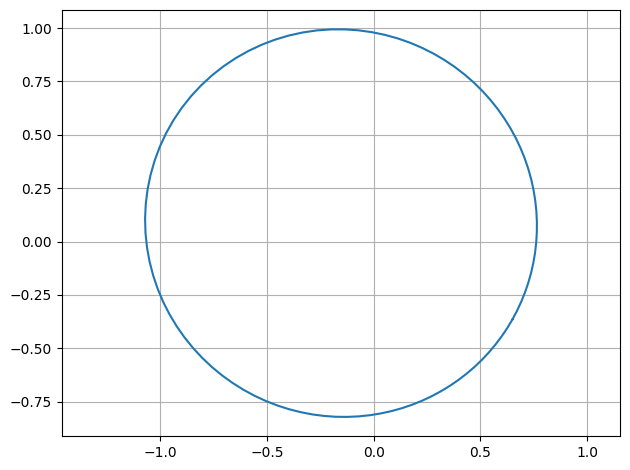

In [7]:
fs = np.linspace(0, 2*np.pi, 100)

p = q * (1 + e)
rs = p / (1 + e*np.cos(fs))

xfs = rs * np.cos(fs)
yfs = rs * np.sin(fs)
zfs = np.zeros_like(xfs)

# Este comando hace la multiplicación matricial
rvecs = (R_peri2astro @ np.array([xfs, yfs, zfs])).T

plt.plot(rvecs[:,0], rvecs[:,1])
plt.axis('equal')
plt.grid()
plt.tight_layout()

In [ ]:
pym.elementos_a_estados(a, e, i, node, peri, 0)


Signature: pym.elementos_a_estado(mu, elementos)
Source:   
def elementos_a_estado(mu,elementos):
    """Convierte elementos orbitales clasicos a estado cartesiano.

    Parameters
    ----------
    mu : float
        Parametro gravitacional.
    elementos : array-like
        `(p, e, i, W, w, f)`.

    Returns
    -------
    numpy.ndarray
        Vector `(x, y, z, vx, vy, vz)`.

    Examples
    --------
    >>> x = elementos_a_estado(mu, array([p, e, i, W, w, f]))
    """
    #Extrae elementos
    p,e,i,W,w,f=elementos
    
    #Calcula momento angular relativo específico
    h=sqrt(mu*p)
    
    #Calcula r
    r=p/(1+e*cos(f))
    
    #Posición
    x=r*(cos(W)*cos(w+f)-cos(i)*sin(W)*sin(w+f))
    y=r*(sin(W)*cos(w+f)+cos(i)*cos(W)*sin(w+f))
    z=r*sin(i)*sin(w+f)
    
    #Velocidad
    muh=mu/h

    vx=muh*(-cos(W)*sin(w+f)-cos(i)*sin(W)*cos(w+f))       -muh*e*(cos(W)*sin(w)+cos(w)*cos(i)*sin(W))
    vy=muh*(-sin(W)*sin(w+f)+cos(i)*cos(W)*cos(w+f))       +muh*e*(-sin(W)*sin(w)